In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['image.cmap'] = 'gray'

In [5]:
modelFile = 'ssd_mobilenet_frozen_inference_graph.pb'
configFile = '../ssd_mobilenet_v2_coco_2018_03_29.pbtxt'
classFile = '../coco_class_labels.txt'

In [6]:
import requests
from os import path

if(not path.exists(modelFile)):
    print('Downloading MobileNet SSD Model.....')
    url = 'https://opencv-courses.s3.us-west-2.amazonaws.com/ssd_mobilenet_frozen_inference_graph.pb'
    r = requests.get(url)
    with open(modelFile,'wb') as f:
        f.write(r.content)

    print('ssd_mobilenet_frozen_inference_graph Download complete')

ssd_mobilenet_frozen_inference_graph Download complete


In [7]:
#Reading the neural network

net = cv2.dnn.readNetFromTensorflow(modelFile, configFile)

In [8]:
with open(classFile) as fp:
    labels = fp.read().split('\n')
print(sorted(labels))

['', 'airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'blender', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'cell phone', 'chair', 'clock', 'couch', 'cow', 'cup', 'desk', 'dining table', 'dog', 'donut', 'door', 'elephant', 'eye glasses', 'fire hydrant', 'fork', 'frisbee', 'giraffe', 'hair brush', 'hair drier', 'handbag', 'hat', 'horse', 'hot dog', 'keyboard', 'kite', 'knife', 'laptop', 'microwave', 'mirror', 'motorcycle', 'mouse', 'orange', 'oven', 'parking meter', 'person', 'pizza', 'plate', 'potted plant', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sheep', 'shoe', 'sink', 'skateboard', 'skis', 'snowboard', 'spoon', 'sports ball', 'stop sign', 'street sign', 'suitcase', 'surfboard', 'teddy bear', 'tennis racket', 'tie', 'toaster', 'toilet', 'toothbrush', 'traffic light', 'train', 'truck', 'tv', 'umbrella', 'unlabeled', 'vase', 'window', 'wine glass', 'zebra']


In [26]:
#Detect Objects
def detect_objects(net, img):
    '''Object detection on Image '''
    dim = 300
    mean = (0,0,0)

    blob = cv2.dnn.blobFromImage(img,1.0,(dim,dim),mean,True)
    net.setInput(blob)

    objects = net.forward()

    return objects

In [27]:
food_img = cv2.imread('../fruit-vegetable.jpg')
food_objects = detect_objects(net, food_img)

print(f'Detected :{len(food_objects[0][0])} Objects (no confidence filtering)')
first_detected_object = food_objects[0][0][0]
print('First Object : ', first_detected_object)

Detected :100 Objects (no confidence filtering)
First Object :  [ 0.         57.          0.8886346   0.6576171   0.33157063  0.8071592
  0.91620326]


In [28]:
print(food_objects.shape)

(1, 1, 100, 7)


In [54]:
def draw_text(im, text, x, y):
    '''Draw a text label at a given x-y position with a black background'''
    fontface = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.7
    thickness = 1

    textSize = cv2.getTextSize(text, fontface, font_scale, thickness)
    dim = textSize[0]
    baseline = textSize[1]

    cv2.rectangle(im, (x,y), (x+dim[0], y+dim[1]+baseline),(0,0,0),cv2.FILLED)
    cv2.putText(im, text, (x, y + dim[1]),fontface, font_scale, (0,255,255), thickness, cv2.LINE_AA)

In [55]:
def draw_objects(im, objects, threshold = 0.25):
    '''Display a box and text for each detected object exceeding the confidence threshold '''
    rows = im.shape[0]
    cols = im.shape[1]

    for i in range(objects.shape[2]):
        classId = int(objects[0,0,i,1])
        score = float(objects[0,0,i,2])
        #Due to the setup as int. Code didnt recognise any of the objects

        #Recover original coordinates from normalized coordinates
        x = int(objects[0,0,i,3] * cols)
        y = int(objects[0,0,i,4] * rows)
        w = int(objects[0,0,i,5] * cols - x)
        h = int(objects[0,0,i,6] * rows - y)

        if score > threshold:
            draw_text(im, "{}".format(labels[classId]), x, y)
            cv2.rectangle(im, (x,y),(x+w, y+h), (255,255,255), 2)

    mp_img = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    return mp_img

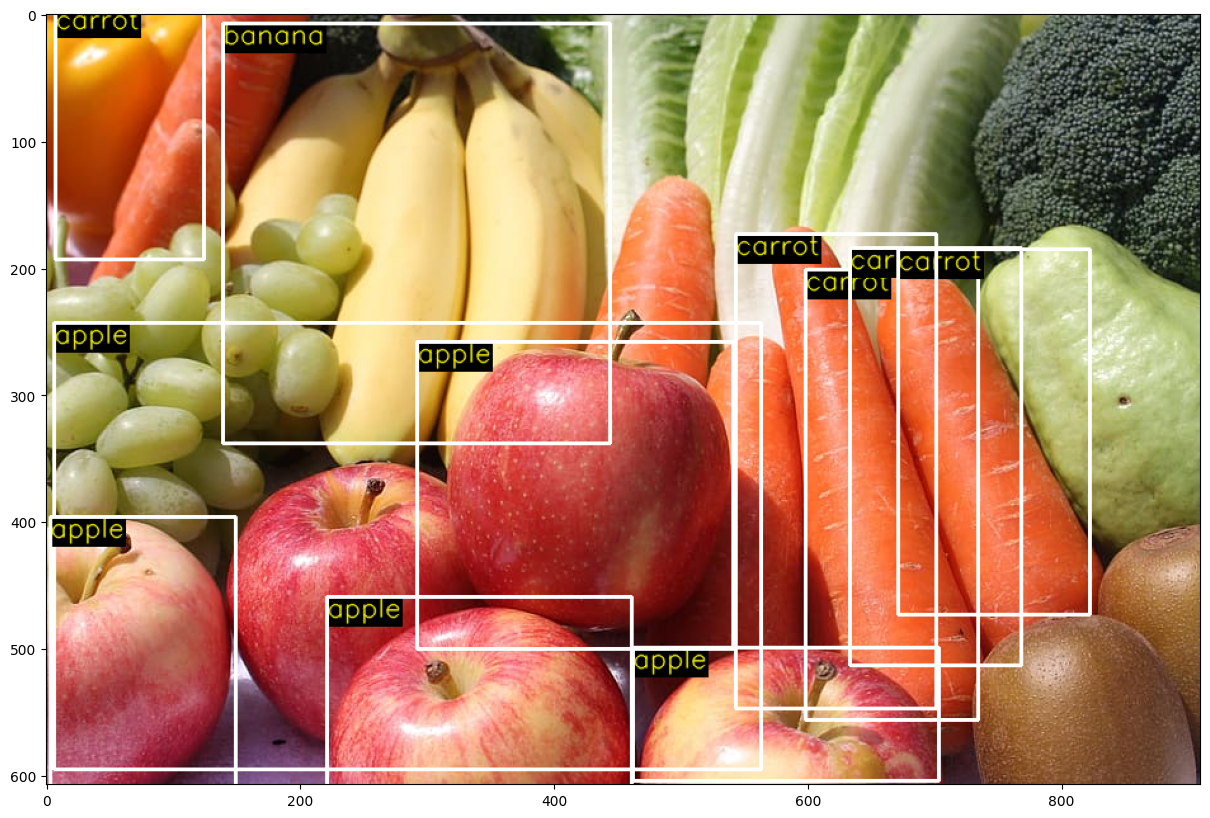

In [56]:
result = draw_objects(food_img.copy(), food_objects,0.4)
plt.figure(figsize=(30,10)); plt.imshow(result);plt.show()

In [57]:
traffic_img = cv2.imread('../traffic.jpg')
traffic_objects = detect_objects(net, traffic_img)

In [59]:
low = draw_objects(traffic_img.copy(), traffic_objects, 0.1)
med = draw_objects(traffic_img.copy(), traffic_objects, 0.4)
hig = draw_objects(traffic_img.copy(), traffic_objects, 0.9)

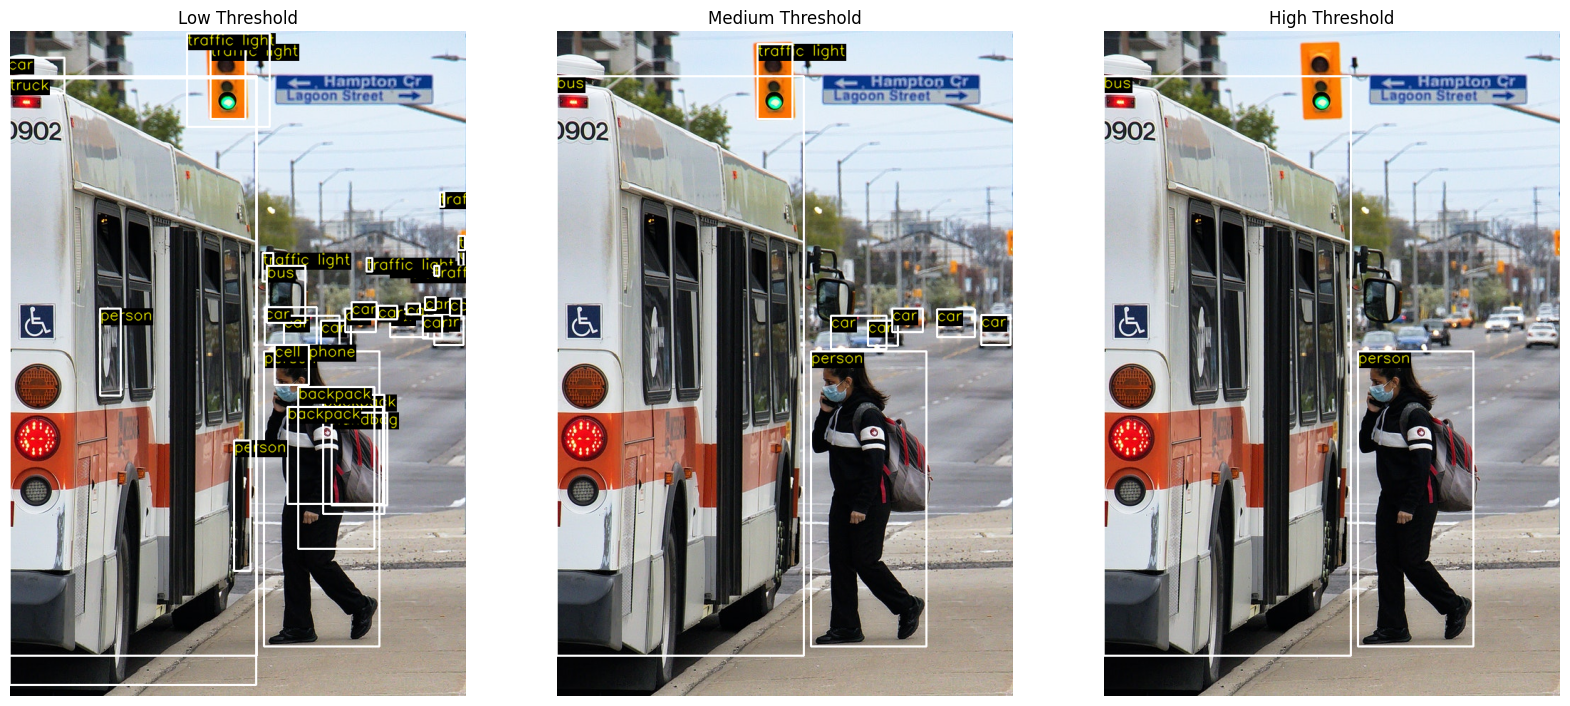

In [61]:
plt.figure(figsize=(20,10))
plt.subplot(131);plt.imshow(low);plt.axis('off');plt.title("Low Threshold")
plt.subplot(132);plt.imshow(med);plt.axis('off');plt.title("Medium Threshold")
plt.subplot(133);plt.imshow(hig);plt.axis('off');plt.title("High Threshold")
plt.show()